# Time Series Forecasting — Daily Bakery Sales

Goal: forecast daily sales volume per product for the next $h = 7$ days.

Roadmap: EDA → baselines → (S)ARIMA → cross-validation → exogenous variables → calendar/Fourier features.

`statsforecast` expects the **long format**: `unique_id` (series key), `ds` (timestamp), `y` (target). Every model below is fit **per series** independently.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  

from utilsforecast.plotting import plot_series  
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * 

from statsforecast import StatsForecast 
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

from statsforecast.models import AutoARIMA

import warnings
warnings.filterwarnings('ignore')

d:\User\vscode\timeseries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_raw = pd.read_csv('data/daily_sales_french_bakery.csv', parse_dates=['ds'])
df = df_raw.groupby('unique_id').filter(lambda x: len(x) >= 28)
df = df.drop(['unit_price'], axis=1)
df.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


Series shorter than 28 days are dropped -- with a weekly season we need at least a few full cycles to estimate anything seasonal (and 28 days = 4 windows of 7). `unit_price` is dropped for now and brought back later as an exogenous feature.

In [3]:
print("unique products in the data : ", len(df.unique_id.unique()))
print("example: ", ", ".join(df.unique_id.unique()[:5]), "etc..")
print("raw data shape : ", df_raw.shape)

unique products in the data :  121
example:  12 MACARON, BAGUETTE, BAGUETTE APERO, BAGUETTE GRAINE, BANETTE etc..
raw data shape :  (57046, 4)


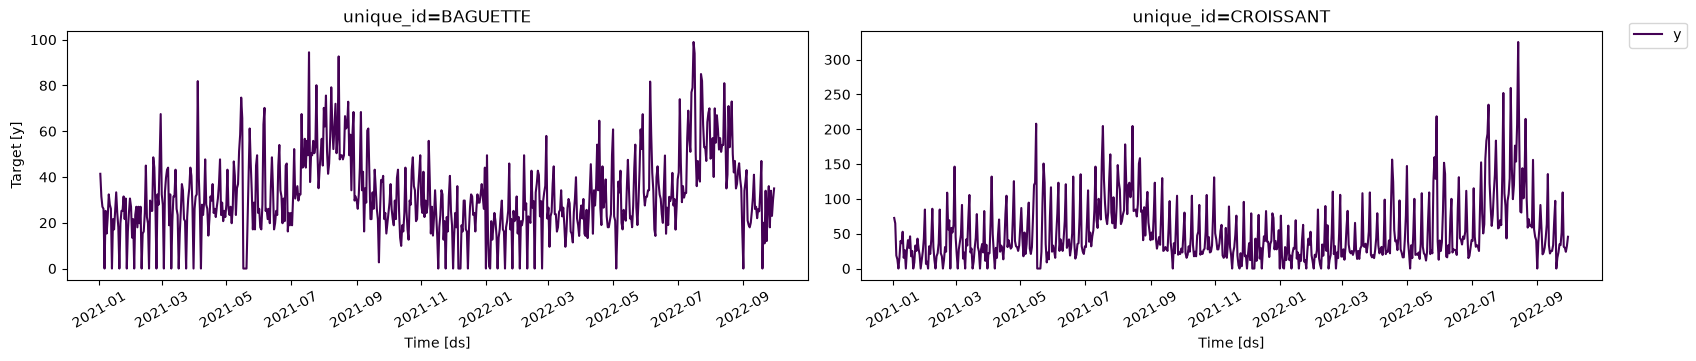

In [4]:
plot_series(df=df, ids=['BAGUETTE', "CROISSANT"], palette="viridis")

only last 56 dates

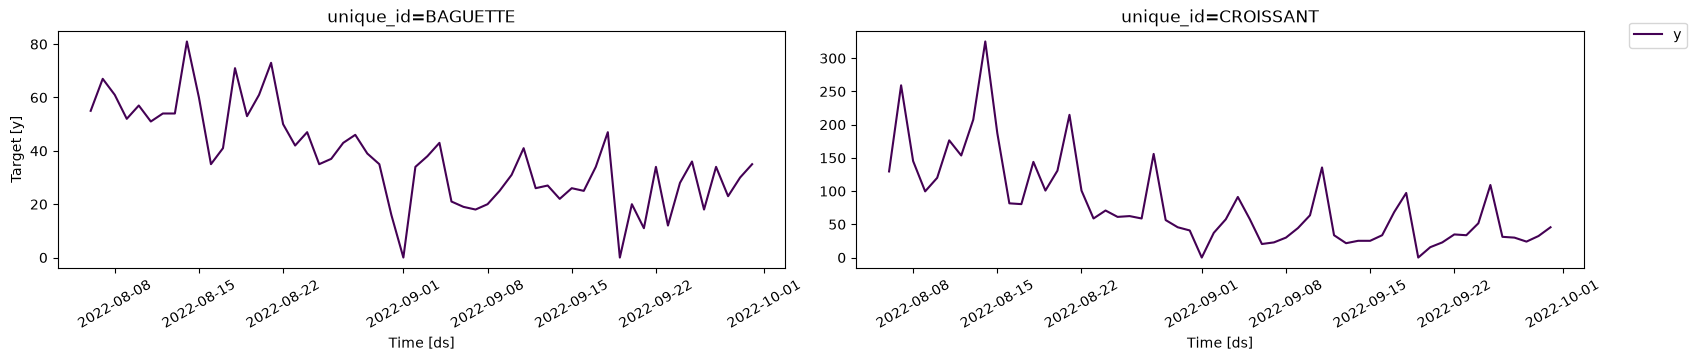

In [5]:
plot_series(df=df, ids=['BAGUETTE', "CROISSANT"],max_insample_length=56, palette="viridis")

**Observations from the EDA plots**

- A repeating **7-day cycle** dominates: the same weekday pattern comes back week after week $\rightarrow$ `season_length = 7`.
- No strong long-run trend over this window -- the level is roughly stable, so trend-heavy models are not the priority.
- Sales are **counts, non-negative, and spiky** (occasional zeros / closed days). Big isolated spikes are outliers, not signal.
- Because of the seasonality, *any* model that ignores the weekday will systematically under/over-shoot on the same days.

### Baseline models

Baselines are the bar any fancy model has to clear. With history $y_1,\dots,y_T$ and horizon $h$:

| Model | Forecast $\hat{y}_{T+h}$ | Assumption |
|---|---|---|
| Naive | $y_T$ | random walk -- last value is the best guess |
| HistoricAverage | $\frac{1}{T}\sum_{t=1}^{T} y_t$ | stationary around a constant mean |
| WindowAverage($k$) | $\frac{1}{k}\sum_{t=T-k+1}^{T} y_t$ | slowly moving level, recent past matters most |
| SeasonalNaive($m$) | $y_{T+h-m\lceil h/m \rceil}$ | last observed *same weekday* repeats |

All four give a **flat** (or flat-seasonal) forecast -- the horizon does not change the shape, only which value is repeated.

In [6]:
horizon = 7 # forecast for next week 
models = [
    Naive(), # last value 
    HistoricAverage(), # historic avg 
    WindowAverage(window_size=7), # avg of last 7 days 
    SeasonalNaive(season_length=7) # we see a seasonality of 1 week in the chart above 
]

sf = StatsForecast(models=models,freq = "D")
sf.fit(df=df)
preds = sf.predict(h=horizon)

preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


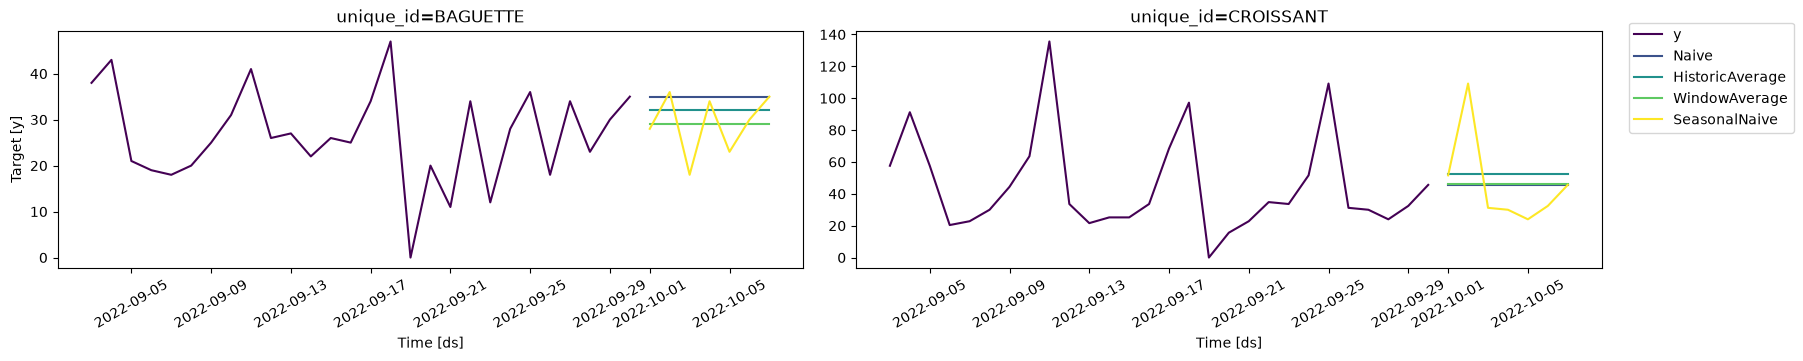

In [7]:
plot_series(
    df = df, forecasts_df=preds, ids=['BAGUETTE', "CROISSANT"], 
    max_insample_length=28, palette="viridis"
)

### Evaluation of baseline model 

**Holdout split.** The last 7 observations of *each* series are the test set; everything before is training. The split is by time, never random -- shuffling would leak the future into the past.

**Metric.**

$$\text{MAE} = \frac{1}{h}\sum_{t=1}^{h}\left| y_t - \hat{y}_t \right|$$

MAE is in the units of the target (loaves/pastries sold) and is robust to the spikes seen above; RMSE would punish those outlier days much harder. Note that averaging MAE across 121 products lets high-volume items dominate -- a scale-free metric (MASE, sMAPE) is the fairer cross-product comparison.

In [8]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

sf.fit(df=train)
preds=sf.predict(h=horizon)
eval_df = pd.merge(test, preds, "left", ["ds", "unique_id"])

In [9]:
evaluation = evaluate(
    eval_df, metrics=[mae]
)

evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [10]:
evaluation = evaluation.drop(['unique_id'], axis = 1).groupby("metric").mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


with seasonal data seasonalnvaive is the best baseline model for future evaluation 

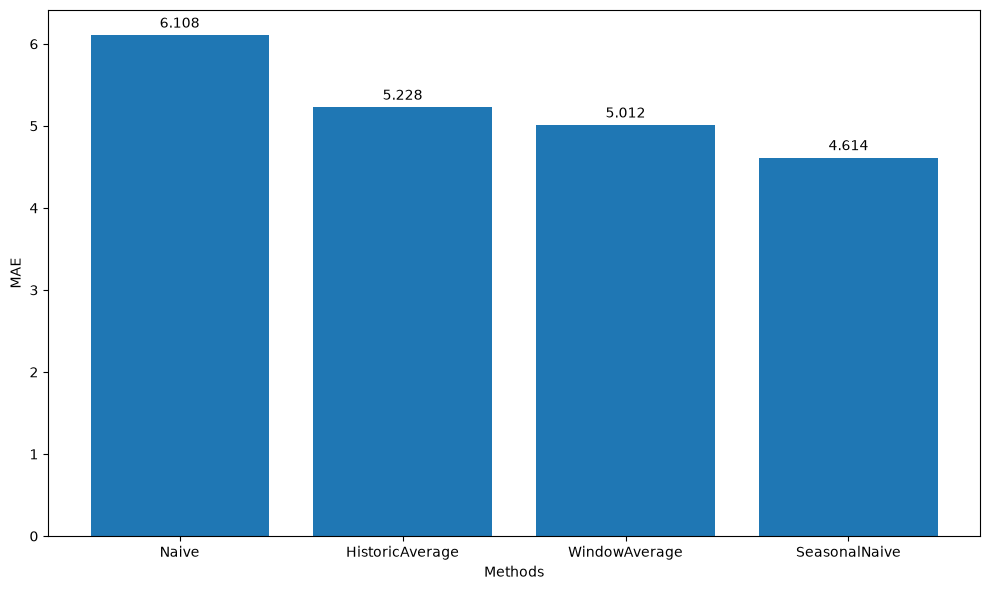

In [11]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist() 
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values): 
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha = 'center', va='bottom')

plt.xlabel('Methods')
plt.ylabel('MAE')
plt.tight_layout()

plt.show()

### Auto ARIMA 

ARIMA$(p,d,q)$ models the series after $d$ differences as a mix of its own past values (AR) and past errors (MA):

$$\phi_p(B)\,(1-B)^d y_t = \theta_q(B)\,\varepsilon_t$$

where $B$ is the backshift operator ($B y_t = y_{t-1}$), $\phi_p$ the AR polynomial and $\theta_q$ the MA polynomial.

SARIMA$(p,d,q)(P,D,Q)_m$ adds the same structure at the seasonal lag $m = 7$:

$$\Phi_P(B^m)\,\phi_p(B)\,(1-B^m)^D (1-B)^d y_t = \Theta_Q(B^m)\,\theta_q(B)\,\varepsilon_t$$

`AutoARIMA` searches over the orders and keeps the lowest **AICc**, so we don't hand-pick $(p,d,q)$. Fitting is per series and is the slow part -- hence only two products here.

In [12]:
unique_ids = ['BAGUETTE', "CROISSANT"]

small_train = train[train['unique_id'].isin(unique_ids)]
small_test = test[test['unique_id'].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias = 'ARIMA'), 
    AutoARIMA(season_length=7, alias ='SARIMA')
]

sf = StatsForecast(models=models, freq='D')
sf.fit(df=small_train)

arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df, metrics = [mae]
)

arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,mae,9.353153,7.449083,17.142857,5.455193,7.877551,12.571429
1,CROISSANT,mae,14.565395,10.359143,17.485714,22.618934,18.244898,12.857143


ARIMA and SARIMA both works better than baseline 

In [13]:
arima_eval = arima_eval.drop(['unique_id'], axis = 1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


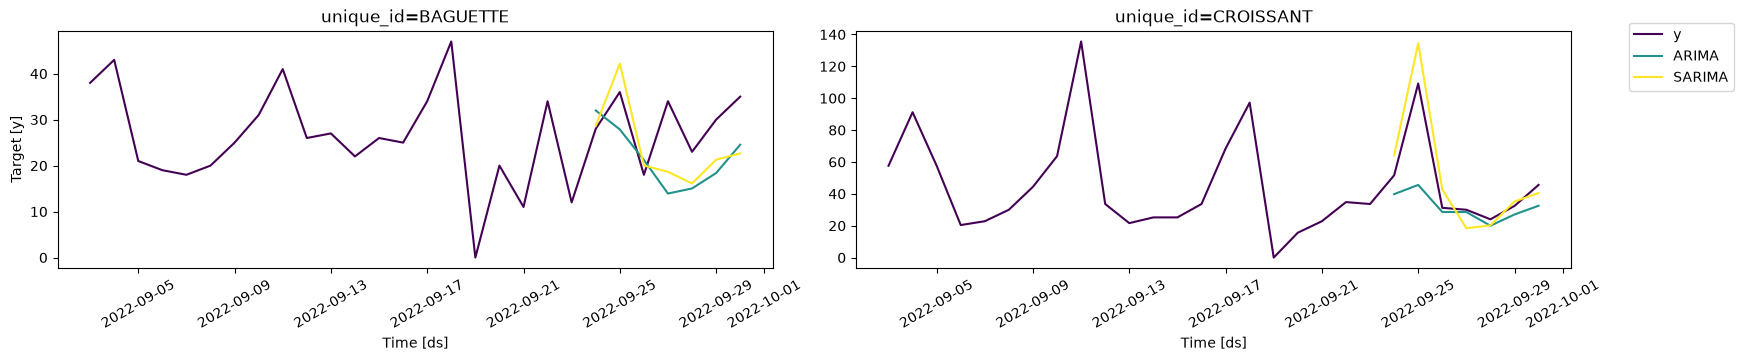

In [14]:
plot_series(
    df=df, forecasts_df=arima_preds, 
    ids = ['BAGUETTE', "CROISSANT"], 
    max_insample_length=28, 
    palette='viridis'
)

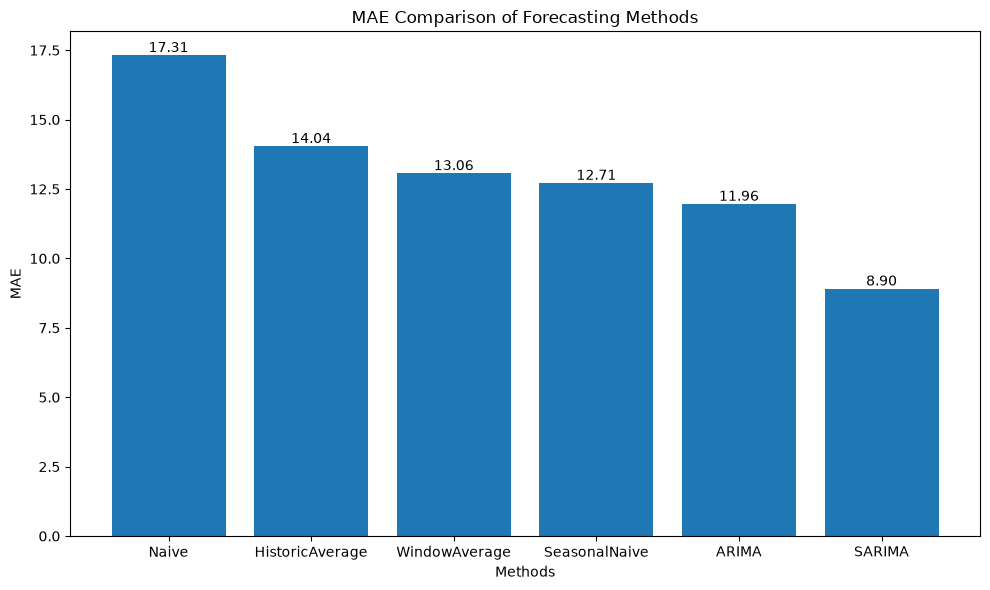

In [15]:
methods = arima_eval.columns[1:].tolist()
values = arima_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x-coordinate
        height,                             # y-coordinate
        f'{height:.2f}',                    # Label (2 decimal places)
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Methods')
plt.ylabel('MAE')
plt.title('MAE Comparison of Forecasting Methods')
plt.tight_layout()

plt.show()

**Caveat:** this ranking comes from **one** 7-day window on **two** products -- 14 error terms in total. That is far too little to declare a winner; a single bad Sunday can flip the order. The next section re-scores everything over several windows.

### Cross validation 

**Rolling-origin (time-series) cross-validation.** Instead of one holdout, slide the cutoff forward and re-evaluate:

```
window 1: |--------- train ---------| test |
window 2: |------------ train ------------| test |
window 3: |--------------- train ---------------| test |
```

- `n_windows=8`, `step_size=h=7` $\rightarrow$ 8 non-overlapping test blocks, $8 \times 7 = 56$ forecast points per series.
- `refit=True` re-estimates the model at every cutoff -- slower, but honest: the model only ever sees data before its `cutoff`.
- `cutoff` marks the last training timestamp of the window a row belongs to.

The reported score is the average over windows, so it is far less hostage to one unlucky week.

In [16]:
small_df = df[df['unique_id'].isin(unique_ids)]

models = [
    SeasonalNaive(season_length=7), 
    AutoARIMA(seasonal=False, alias="ARIMA"), 
    AutoARIMA(season_length=7, alias='SARIMA'), 
]

sf = StatsForecast(models=models, freq='D')
cross_val_df = sf.cross_validation(
    h=horizon, 
    df = small_df, 
    n_windows=8, # 8x7 = 56 ~ reasonable sample size. higher the better 
    step_size=horizon, # to have non overlapping window 
    refit = True, #makes it slower but better
)

# cutoff is where the model stopped training 
cross_val_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA
0,BAGUETTE,2022-08-06,2022-08-05,55.0,68.0,71.355196,71.584713
1,BAGUETTE,2022-08-07,2022-08-05,67.0,70.0,70.337980,78.458883
2,BAGUETTE,2022-08-08,2022-08-05,61.0,48.0,61.195004,57.001732
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.0,52.649013,49.401144
4,BAGUETTE,2022-08-10,2022-08-05,57.0,57.0,47.785876,49.725278


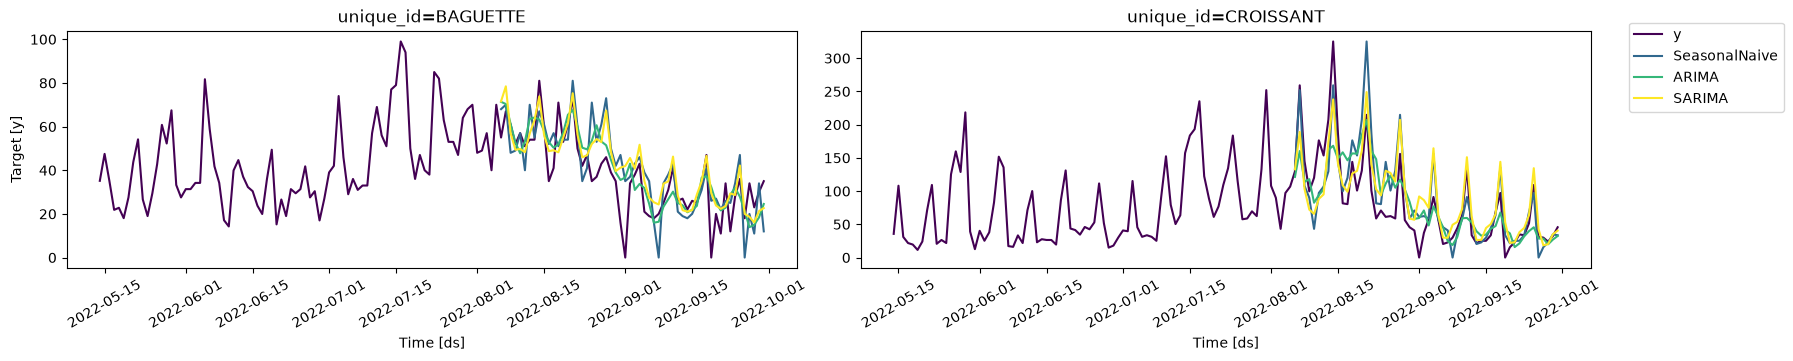

In [17]:
# done it multiple times 
plot_series(
    df=small_df, forecasts_df = cross_val_df.drop(['y', 'cutoff'], axis = 1), 
    ids = ['BAGUETTE', "CROISSANT"], 
    max_insample_length= 140, 
    palette = 'viridis'
)

ARIMA performs worse than seasonal naive (baseline)

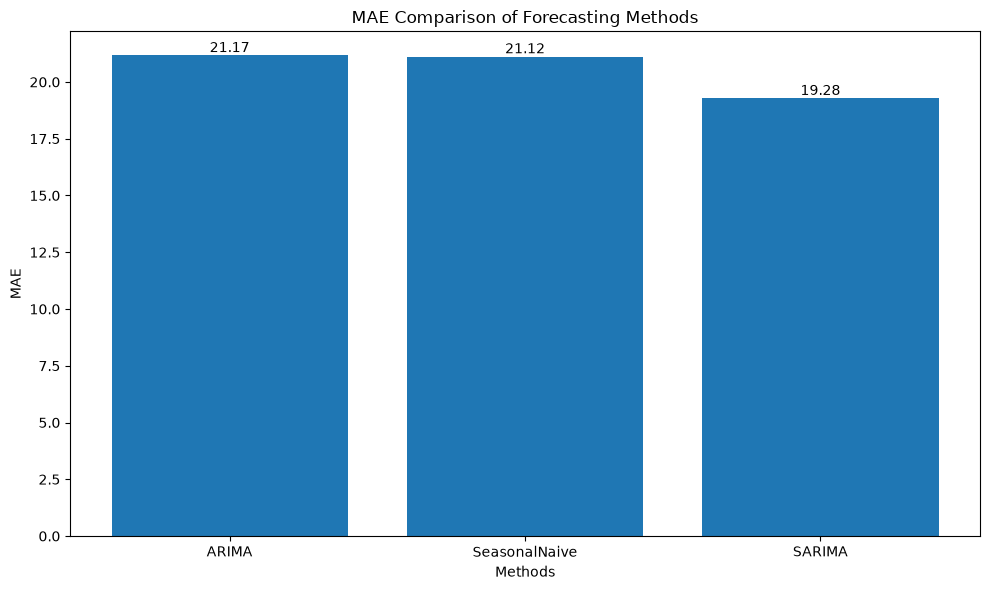

In [18]:
cv_eval = evaluate(
    cross_val_df.drop(['cutoff'], axis=1), 
    metrics=[mae]
)
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()

methods = cv_eval.columns[1:].tolist()
values = cv_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x-coordinate
        height,                             # y-coordinate
        f'{height:.2f}',                    # Label (2 decimal places)
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Methods')
plt.ylabel('MAE')
plt.title('MAE Comparison of Forecasting Methods')
plt.tight_layout()

plt.show()

**Takeaway:** the single-window ranking did not survive. Averaged over 8 windows, non-seasonal ARIMA is the worst -- it has no mechanism for the weekday effect -- and the gap to SeasonalNaive shrinks. Complexity only pays off when it captures structure the baseline misses (here: the seasonal term).

### Exogenous features 

Exogenous variables are extra regressors $x_t$ (here `unit_price`). SARIMAX = regression with SARIMA errors:

$$y_t = \beta^\top x_t + n_t, \qquad n_t \sim \text{SARIMA}(p,d,q)(P,D,Q)_m$$

The catch: to forecast $y_{T+h}$ you need $x_{T+h}$ **known in advance** -- hence `X_df=future_exog_df`. That is fine for price (set by the shop) or holidays/weather forecasts, but not for anything you would have to predict first.

Any column in the training frame other than `unique_id`, `ds`, `y` is picked up automatically as exogenous.

In [19]:
df_raw = pd.read_csv('data/daily_sales_french_bakery.csv', parse_dates=['ds'])
df = df_raw.groupby('unique_id').filter(lambda x: len(x) >= 28) 
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


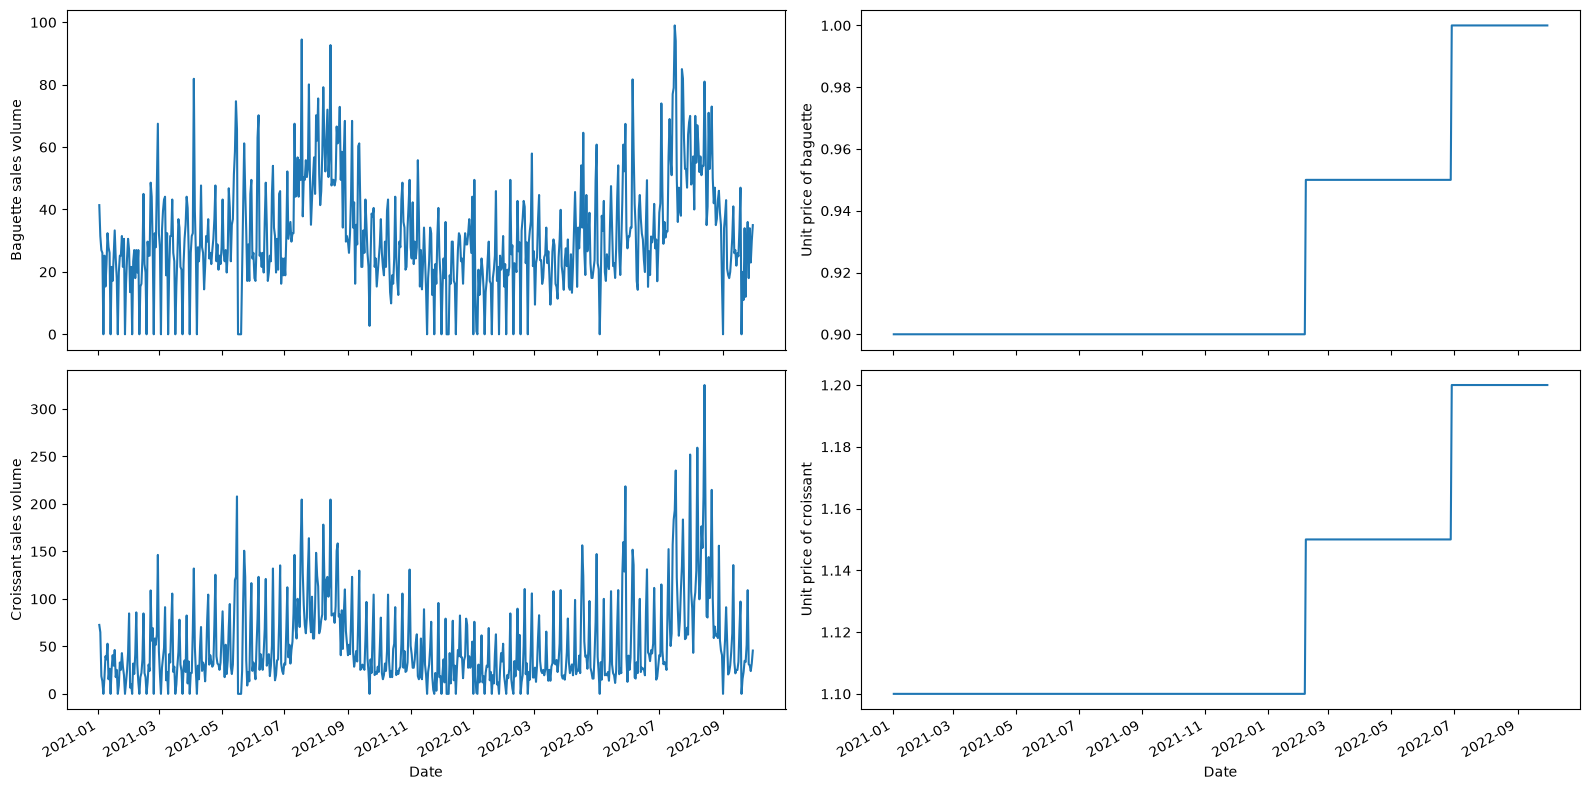

In [20]:
baguette_plot_df = df[df["unique_id"] == "BAGUETTE"]
croissant_plot_df = df[df["unique_id"] == "CROISSANT"]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16,8))

ax1.plot(baguette_plot_df["ds"], baguette_plot_df["y"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Baguette sales volume")

ax2.plot(baguette_plot_df["ds"], baguette_plot_df["unit_price"])
ax2.set_xlabel("Date")
ax2.set_ylabel("Unit price of baguette")

ax3.plot(croissant_plot_df["ds"], croissant_plot_df["y"])
ax3.set_xlabel("Date")
ax3.set_ylabel("Croissant sales volume")

ax4.plot(croissant_plot_df["ds"], croissant_plot_df["unit_price"])
ax4.set_xlabel("Date")
ax4.set_ylabel("Unit price of croissant")

fig.autofmt_xdate()
plt.tight_layout()

In [21]:
small_df = df[df['unique_id'].isin(unique_ids)]
test = small_df.groupby('unique_id').tail(7)
train = small_df.drop(test.index).reset_index(drop=True)

In [22]:
# needed for statistical models 
future_exog_df = test.drop(['y'], axis=1)
future_exog_df.head()

,unique_id,ds,unit_price
714,BAGUETTE,2022-09-24,1.0
715,BAGUETTE,2022-09-25,1.0
716,BAGUETTE,2022-09-26,1.0
717,BAGUETTE,2022-09-27,1.0
718,BAGUETTE,2022-09-28,1.0


In [23]:
# SARIMA with exog features 
models = [AutoARIMA(season_length=7, alias='SARIMA_exog')]
sf = StatsForecast(models=models, freq='D')
sf.fit(df=train)
arima_exog_preds = sf.predict(h=horizon, X_df=future_exog_df)

# SARIMA without exog features 
models = [AutoARIMA(season_length=7, alias='SARIMA')]
sf = StatsForecast(models=models, freq='D')
sf.fit(df=train.drop(['unit_price'], axis=1))
arima_preds = sf.predict(h=horizon)

In [24]:
test_df = test.merge(arima_exog_preds, on=["unique_id", "ds"], how="left")\
              .merge(arima_preds, on=["unique_id", "ds"], how="left")
test_df

,unique_id,ds,y,unit_price,SARIMA_exog,SARIMA
0,BAGUETTE,2022-09-24,28.0,1.0,28.898898,28.657114
1,BAGUETTE,2022-09-25,36.0,1.0,42.513264,42.182373
2,BAGUETTE,2022-09-26,18.0,1.0,20.423976,20.013652
3,BAGUETTE,2022-09-27,34.0,1.0,19.066264,18.646490
4,BAGUETTE,2022-09-28,23.0,1.0,16.468885,16.114925
5,BAGUETTE,2022-09-29,30.0,1.0,21.656726,21.288019
6,BAGUETTE,2022-09-30,35.0,1.0,23.101235,22.660124
7,CROISSANT,2022-09-24,51.6,1.2,64.427509,64.011002
8,CROISSANT,2022-09-25,109.2,1.2,135.128194,134.488202
9,CROISSANT,2022-09-26,31.2,1.2,43.530880,42.735407


`SARIMA_exog` and `SARIMA` differ by well under a unit on every row -- `unit_price` is essentially constant per product over the test week, and a constant regressor carries no information beyond the intercept. An exogenous variable only helps when it **varies** and that variation moves the target.

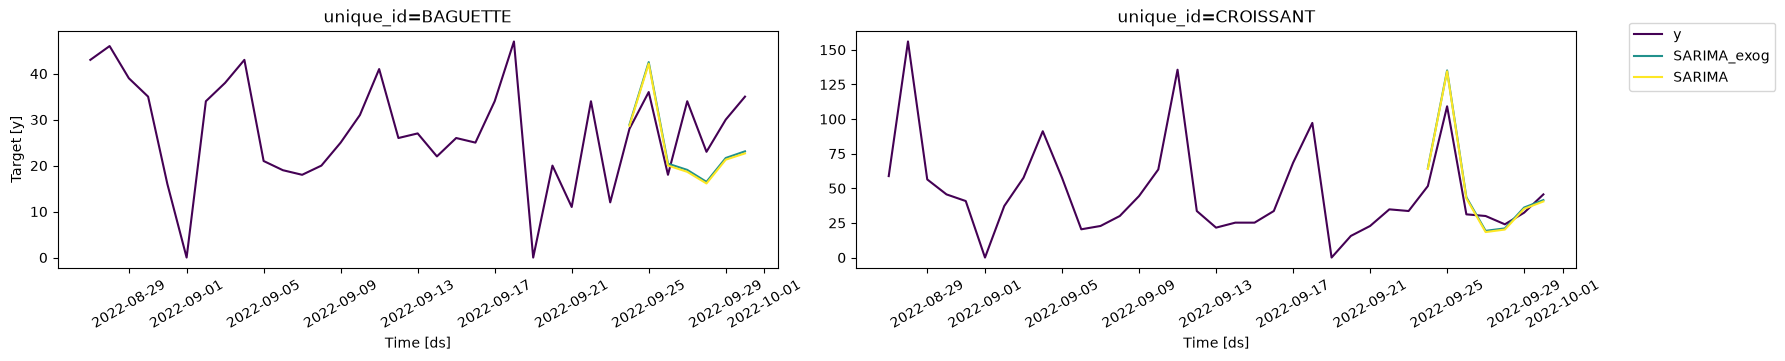

In [25]:
plot_series(
    df=train, 
    forecasts_df=test_df, 
    ids=["BAGUETTE", "CROISSANT"], 
    max_insample_length=28,
    models=["SARIMA_exog", "SARIMA"],
    palette="viridis"
)

In [26]:
models = [ 
    AutoARIMA(season_length=7, alias='SARIMAP_exog'), 
]

sf = StatsForecast(models=models, freq='D')

# will automatically detect exog features 
cross_val_exog_df = sf.cross_validation(
    h=horizon, 
    df = small_df, 
    n_windows=8,  
    step_size=horizon,  
    refit = True,  
)
 
cross_val_exog_df.head()

,unique_id,ds,cutoff,y,SARIMAP_exog
0,BAGUETTE,2022-08-06,2022-08-05,55.0,71.511528
1,BAGUETTE,2022-08-07,2022-08-05,67.0,78.458054
2,BAGUETTE,2022-08-08,2022-08-05,61.0,57.062745
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.525901
4,BAGUETTE,2022-08-10,2022-08-05,57.0,49.485683


In [27]:
cv_exog_eval = evaluate(
    cross_val_exog_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_exog_eval = cv_exog_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_exog_eval

,metric,SARIMAP_exog
0,mae,19.210264


Same 2 products, same 8 windows as the CV above, so this score is directly comparable to the plain `SARIMA` bar there -- compare them before concluding that price helped.

### Creating features from timestamp 

Instead of seasonal AR/MA terms, seasonality can be encoded as **deterministic regressors** built from the timestamp alone -- which means they are always known for the future.

**Fourier terms** -- $K$ sine/cosine pairs at season length $m$:

$$x_{k,t} = \left\{ \sin\!\left(\frac{2\pi k t}{m}\right),\ \cos\!\left(\frac{2\pi k t}{m}\right) \right\}_{k=1}^{K}$$

With $m=7,\ K=2$ that is 4 smooth columns replacing 6 weekday dummies -- fewer parameters, and it extrapolates cleanly.

**Calendar features** -- `day`, `week`, `month` extracted from `ds`, for effects Fourier terms cannot express (month-end, payday).

`pipeline(...)` returns both the augmented training frame and the matching future frame `futr_exog_df` for the next `h` steps, so the two stay aligned.

In [28]:
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

In [29]:
features = [
    partial(fourier, season_length=7, k=2), # how many sin and cos you want to encode the info, higher ther better for complex data 
    partial(time_features, features=["day", "week", "month"])
]

small_exog_df, futr_exog_df = pipeline(
    df=small_df,
    features=features,
    freq="D",
    h=horizon
)

In [30]:
small_exog_df.head()

,unique_id,ds,y,unit_price,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
84,BAGUETTE,2021-01-02,41.4,0.9,0.781832,0.974928,0.623490,-0.222521,2,53,1
85,BAGUETTE,2021-01-03,31.5,0.9,0.974928,-0.433884,-0.222521,-0.900969,3,53,1
86,BAGUETTE,2021-01-04,27.0,0.9,0.433884,-0.781831,-0.900969,0.623490,4,1,1
87,BAGUETTE,2021-01-05,26.1,0.9,-0.433884,0.781832,-0.900969,0.623490,5,1,1
88,BAGUETTE,2021-01-06,0.0,0.9,-0.974928,0.433884,-0.222521,-0.900969,6,1,1


In [31]:
futr_exog_df

,unique_id,ds,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
0,BAGUETTE,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
1,BAGUETTE,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
2,BAGUETTE,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10
3,BAGUETTE,2022-10-04,-0.433861,0.781800,-0.900980,0.623529,4,40,10
4,BAGUETTE,2022-10-05,-0.974933,0.433846,-0.222500,-0.900987,5,40,10
5,BAGUETTE,2022-10-06,-0.781828,-0.974931,0.623495,-0.222509,6,40,10
6,BAGUETTE,2022-10-07,-0.000009,-0.000017,1.000000,1.000000,7,40,10
7,CROISSANT,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
8,CROISSANT,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
9,CROISSANT,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10


Two things to notice in these frames:

- The Fourier columns live in $[-1, 1]$ and repeat every 7 rows; `week` jumps to 53 at the year boundary, so treat it as cyclical rather than ordinal.
- `futr_exog_df` contains the calendar columns but **not** `unit_price` -- `pipeline` can only manufacture what is derivable from `ds`. Any genuinely external regressor still has to be supplied by hand for the future window.

In [32]:
models = [
    AutoARIMA(season_length=7, alias="SARIMA_time_exog")
]

sf = StatsForecast(models=models, freq="D")
cv_time_exog_df = sf.cross_validation(
    h=horizon, # 7 days
    df=small_exog_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

cv_time_exog_eval = evaluate(
    cv_time_exog_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_time_exog_eval = cv_time_exog_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_time_exog_eval

,metric,SARIMA_time_exog
0,mae,16.10915


Same 8-window CV protocol as before, so this is comparable to the earlier scores. Note that `small_exog_df` still carries `unit_price` alongside the new calendar columns, so this run is *SARIMA + price + Fourier + calendar*, not calendar features alone.

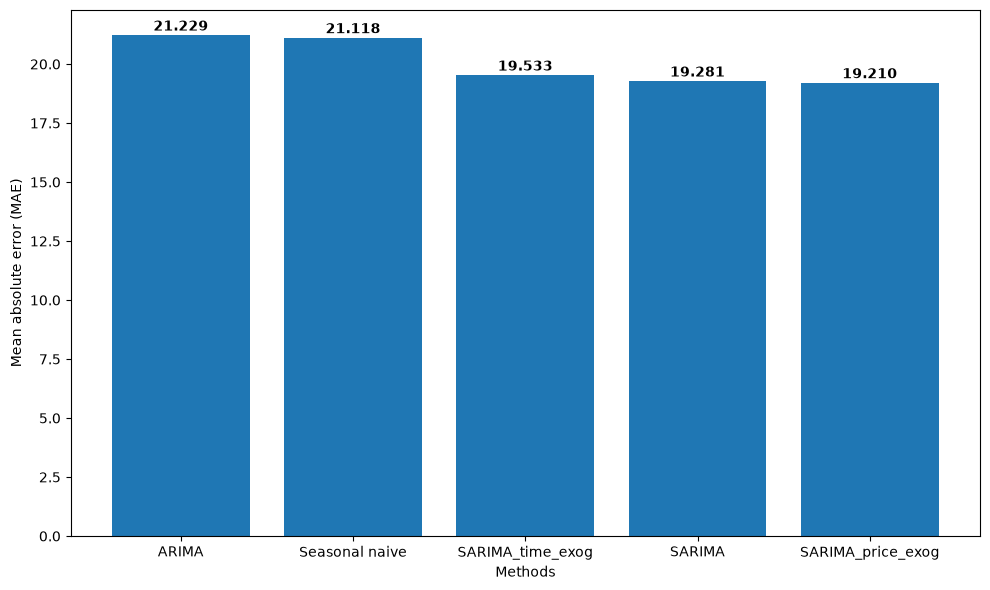

In [33]:
methods = ["ARIMA", "Seasonal naive", "SARIMA", "SARIMA_price_exog", "SARIMA_time_exog"] 
values = [21.229, 21.118, 19.281, 19.210, 19.533]

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

**Takeaway:** every model sits in a narrow band, and SeasonalNaive is within ~2 MAE of the best. When a one-line baseline is that close, the extra fitting cost has to be justified by something other than accuracy.

Careful -- the values in this chart are **hard-coded**, not read from the eval frames, so they drift out of sync when a cell is re-run (the `SARIMA_time_exog` entry does not match the MAE printed just above). Building the frame from the actual `cv_*_eval` results would keep it honest.

### Prediction intervals 

A point forecast says nothing about risk. `level=[80, 99]` asks for intervals such that

$$\hat{y}_{T+h} \pm z_{\alpha/2}\,\hat{\sigma}_h$$

where $\hat{\sigma}_h$ is the model's $h$-step-ahead forecast standard error. Two properties follow from the ARIMA error structure:

- $\hat{\sigma}_h$ **grows with $h$** -- uncertainty compounds as you forecast further out, so the band flares.
- The interval only covers *model* uncertainty (the $\varepsilon_t$ term). It assumes the fitted orders are correct and the residuals are Gaussian, so real-world coverage is usually a bit below nominal.

Output columns arrive as `AutoARIMA-lo-80` / `AutoARIMA-hi-80` and so on.

In [34]:
unique_ids = ["BAGUETTE", "CROISSANT"]
small_df = df[df["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(7)
train = small_df.drop(test.index).reset_index(drop=True)

In [35]:
train.head()

,unique_id,ds,y,unit_price
0,BAGUETTE,2021-01-02,41.4,0.9
1,BAGUETTE,2021-01-03,31.5,0.9
2,BAGUETTE,2021-01-04,27.0,0.9
3,BAGUETTE,2021-01-05,26.1,0.9
4,BAGUETTE,2021-01-06,0.0,0.9


In [46]:
test.drop(["y"], axis=1)

,unique_id,ds,unit_price
714,BAGUETTE,2022-09-24,1.0
715,BAGUETTE,2022-09-25,1.0
716,BAGUETTE,2022-09-26,1.0
717,BAGUETTE,2022-09-27,1.0
718,BAGUETTE,2022-09-28,1.0
719,BAGUETTE,2022-09-29,1.0
720,BAGUETTE,2022-09-30,1.0
13496,CROISSANT,2022-09-24,1.2
13497,CROISSANT,2022-09-25,1.2
13498,CROISSANT,2022-09-26,1.2


In [54]:
models = [
    AutoARIMA(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)
prob_preds = sf.predict(
    h=horizon, X_df=test.drop(["y"], axis=1), level=[80, 99]  # 80 and 99% prediction interval 
)

In [55]:
test_df = test.merge(prob_preds, on=["unique_id", "ds"], how="left")

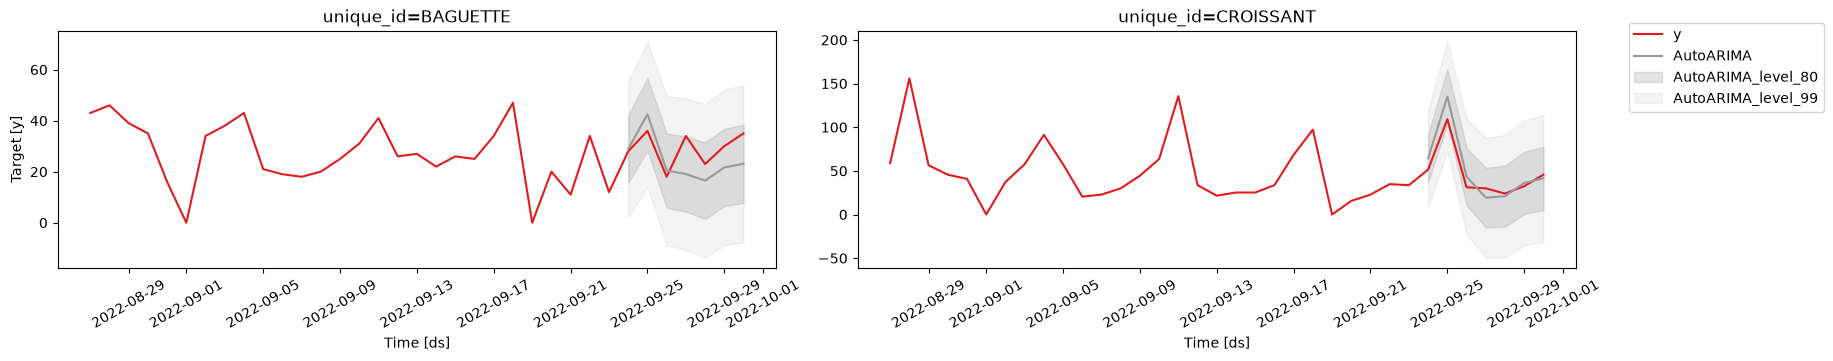

In [57]:
plot_series(
    df=train, 
    forecasts_df=test_df, 
    ids=["BAGUETTE", "CROISSANT"], 
    max_insample_length=28,
    models=["AutoARIMA"],
    level=[80, 99],
    palette="Set1"
)

Worth checking on the plot: the band should widen from day 1 to day 7, and the 99% band should be visibly wider than the 80% one. Also watch the lower bound -- sales are non-negative counts, but a Gaussian interval will happily dip below zero on low-volume days. Clipping at 0 (or modelling on a log/Box-Cox scale) fixes that.

In [58]:
models = [
    AutoARIMA(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
cv_prob_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=7,
    refit=True,
    level=[80, 99],
)

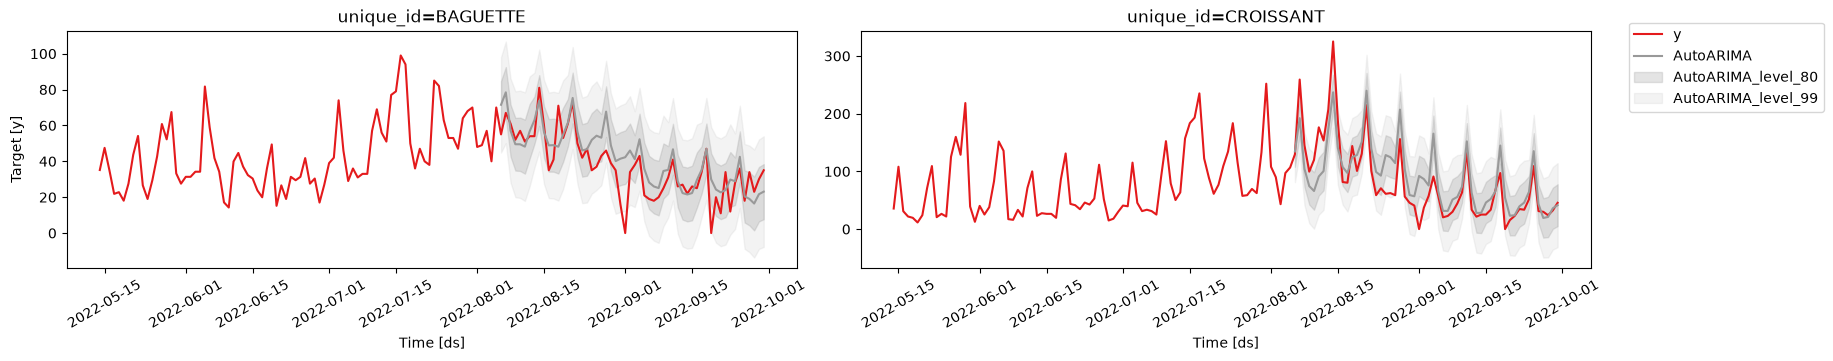

In [59]:
plot_series(
    df=small_df, 
    forecasts_df=cv_prob_df.drop(["y", "cutoff"], axis=1), 
    ids=["BAGUETTE", "CROISSANT"], 
    models=["AutoARIMA"],
    max_insample_length=140,
    level=[80, 99],
    palette="Set1"
)

Cross-validated intervals show the same flare repeating in each of the 8 windows: the band is narrowest right after a `cutoff` and widest at the end of that window's 7 days. Eyeballing how often the actuals fall outside the 80% band is a quick calibration check -- roughly 1 point in 5 should.

### Evaluation metrics

No single number captures forecast quality, so score several. Over $n$ points:

| Metric | Formula | Reads as |
|---|---|---|
| MAE | $\frac{1}{n}\sum \lvert y_t - \hat{y}_t \rvert$ | average miss, in units sold |
| MSE | $\frac{1}{n}\sum (y_t - \hat{y}_t)^2$ | squared error -- punishes big misses |
| RMSE | $\sqrt{\text{MSE}}$ | same, back in original units |
| MAPE | $\frac{1}{n}\sum \frac{\lvert y_t - \hat{y}_t \rvert}{\lvert y_t \rvert}$ | relative error -- **blows up when $y_t = 0$** |
| sMAPE | $\frac{1}{n}\sum \frac{\lvert y_t - \hat{y}_t \rvert}{\lvert y_t \rvert + \lvert \hat{y}_t \rvert}$ | symmetric version, bounded in $[0,1]$ here |
| MASE | $\frac{\text{MAE}}{\text{MAE}_{\text{seasonal naive, in-sample}}}$ | $<1$ beats the naive benchmark, $>1$ loses to it |
| scaled CRPS | quantile loss across the requested `level`s, scaled by total actuals | quality of the whole **distribution**, not just the mean |

Practical notes: MAPE is the wrong choice for this data -- closed days give $y_t = 0$. MASE needs `train_df` to compute its denominator and `seasonality=7` to use the weekly naive. `scaled_crps` needs `level=[80]` in both the forecast and the eval call, and is the only metric here that rewards well-calibrated intervals.

In [41]:
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog"),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
final_cv_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=7,
    refit=True,
    level=[80],
)

In [42]:
final_cv_df.head()

,unique_id,ds,cutoff,y,SARIMA_exog,SARIMA_exog-lo-80,SARIMA_exog-hi-80,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-hi-80
0,BAGUETTE,2022-08-06,2022-08-05,55.0,71.511528,58.279213,84.743843,68.0,50.158042,85.841958
1,BAGUETTE,2022-08-07,2022-08-05,67.0,78.458054,64.354114,92.561995,70.0,52.158042,87.841958
2,BAGUETTE,2022-08-08,2022-08-05,61.0,57.062745,42.622201,71.503290,48.0,30.158042,65.841958
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.525901,34.847356,64.204446,49.0,31.158042,66.841958
4,BAGUETTE,2022-08-10,2022-08-05,57.0,49.485683,34.606853,64.364512,57.0,39.158042,74.841958


In [43]:
temp_test = small_df.groupby("unique_id").tail(7*8)
temp_train = small_df.drop(temp_test.index).reset_index(drop=True)

In [44]:
models = ["SARIMA_exog", "SeasonalNaive"]
metrics = [
    mae,
    mse, 
    rmse, 
    mape, 
    smape,
    partial(mase, seasonality=7),
    scaled_crps
]

final_eval = evaluate(
    final_cv_df.drop(["ds", "cutoff"], axis=1),
    metrics=metrics,
    models=models,
    train_df=temp_train,
    level=[80]
)
final_eval = final_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
final_eval

,metric,SARIMA_exog,SeasonalNaive
0,mae,19.210264,21.117857
1,mape,0.328597,0.376819
2,mase,1.181428,1.328592
3,mse,792.640281,970.417143
4,rmse,24.977651,27.875413
5,scaled_crps,0.153621,0.166451
6,smape,0.168231,0.211317


**Observations**

- `SARIMA_exog` wins on **all seven** metrics, so the ranking is not an artefact of one loss function -- that is the agreement you want before picking a model.
- The margin is modest: ~9% lower MAE, ~18% lower MSE. MSE shows the biggest gap because SeasonalNaive occasionally misses badly and squaring magnifies that.
- **MASE > 1 for both models** (1.18 and 1.33). Both are *worse than a one-step seasonal-naive forecast on the training data* -- expected, since these are 7-step-ahead forecasts against a 1-step benchmark, but it does say the series has little predictable structure beyond the weekday effect.
- `scaled_crps` (0.154 vs 0.166) is the closest race, so the two models' uncertainty estimates are of similar quality even where the point forecasts differ.

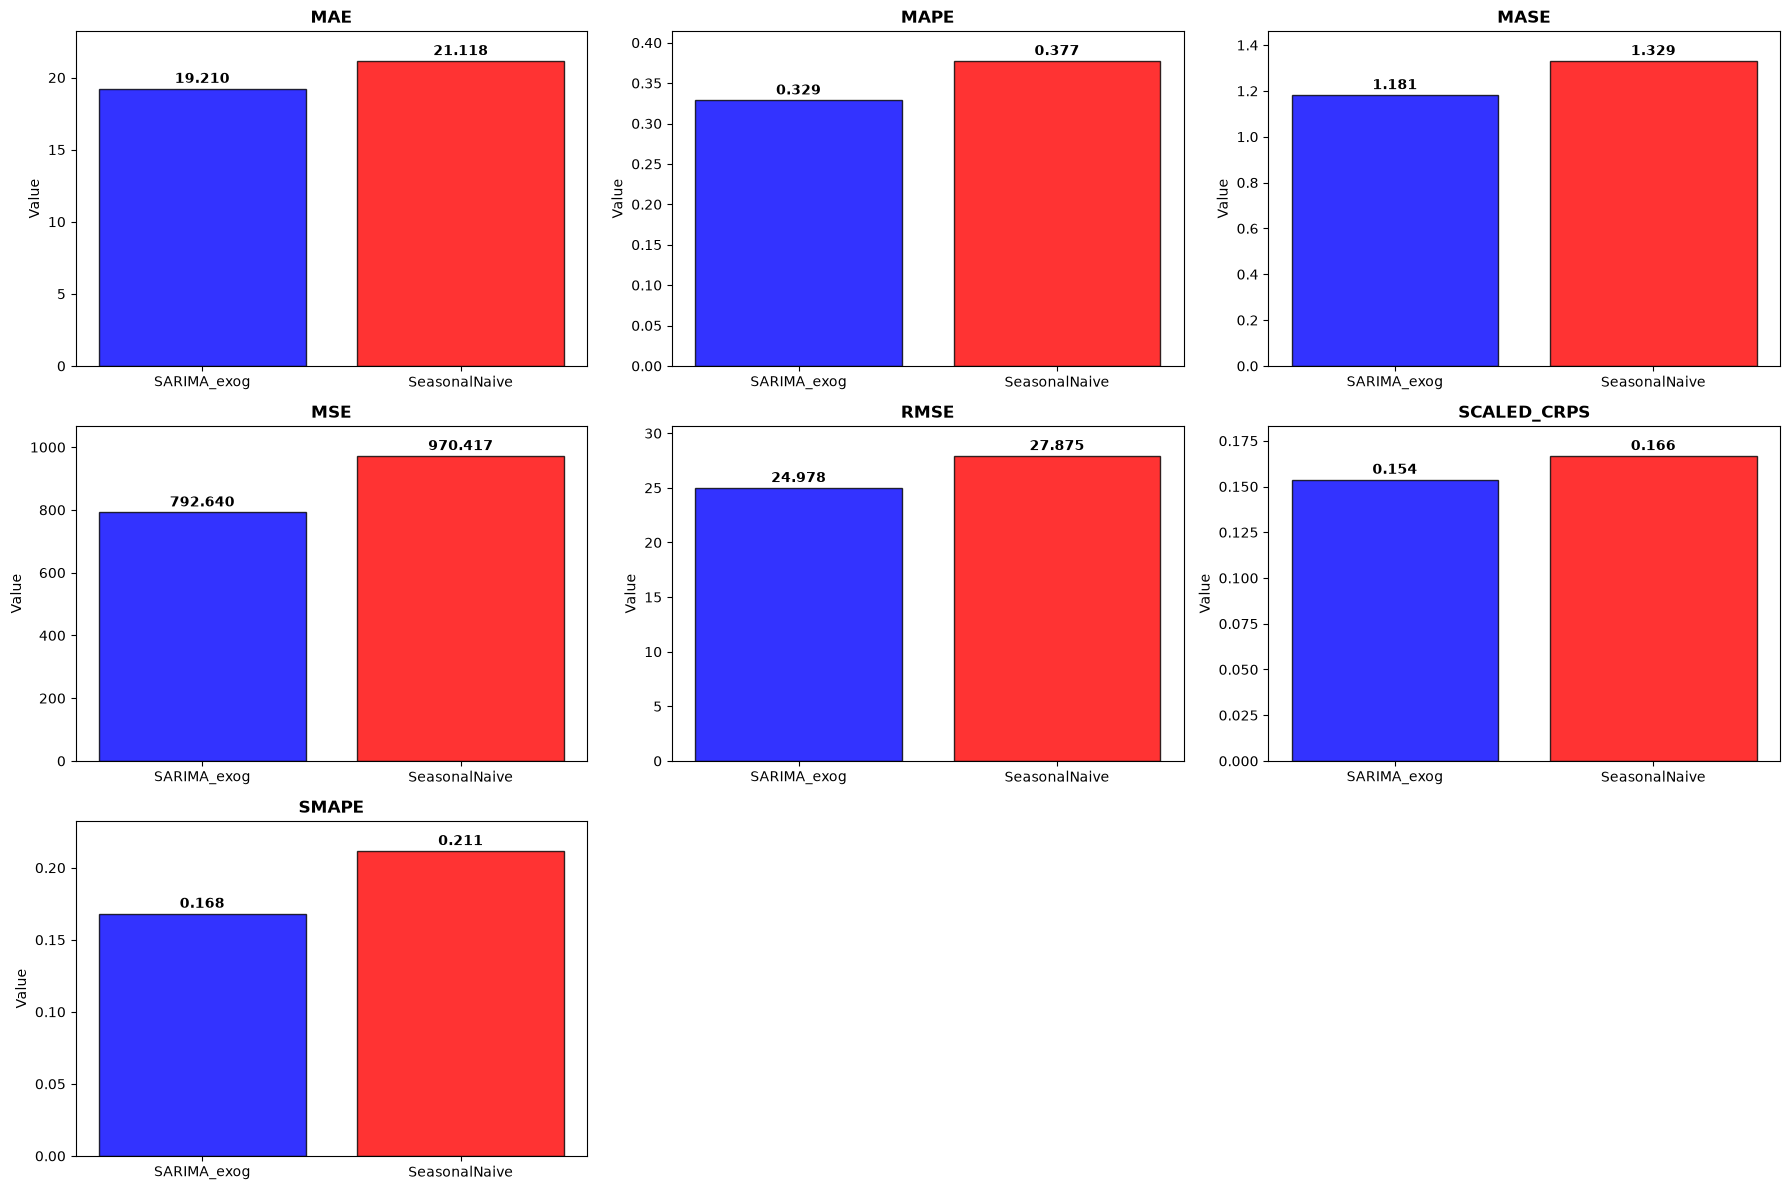

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

axes_flat = axes.flatten()

models = ['SARIMA_exog', 'SeasonalNaive']
x_pos = [0, 1]
colors = ['blue', 'red']

for i, row in final_eval.iterrows():
    ax = axes_flat[i]
    
    model_values = [row['SARIMA_exog'], row['SeasonalNaive']]
    
    bars = ax.bar(x_pos, model_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    
    for j, (bar, value) in enumerate(zip(bars, model_values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_title(row['metric'].upper(), fontweight='bold', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, ha='center')
    ax.set_ylabel('Value')
    max_value = max(model_values)
    ax.set_ylim(0, max_value * 1.1)

fig.delaxes(axes_flat[7])

axes_flat[8].set_visible(False)

plt.tight_layout()
plt.show()